In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [4]:
N_order = 1                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm

alpha = np.arcsin(num_apt / n)

L_ffp = 0.04
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
size = 0.004
bead_img = Bead_Image(grid,  [0], [0], [size])


#CONJUGATE BFP LENGTH

grid_bfp = grid_ffp
L_bfp = (lambd * f * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, grid_bfp)



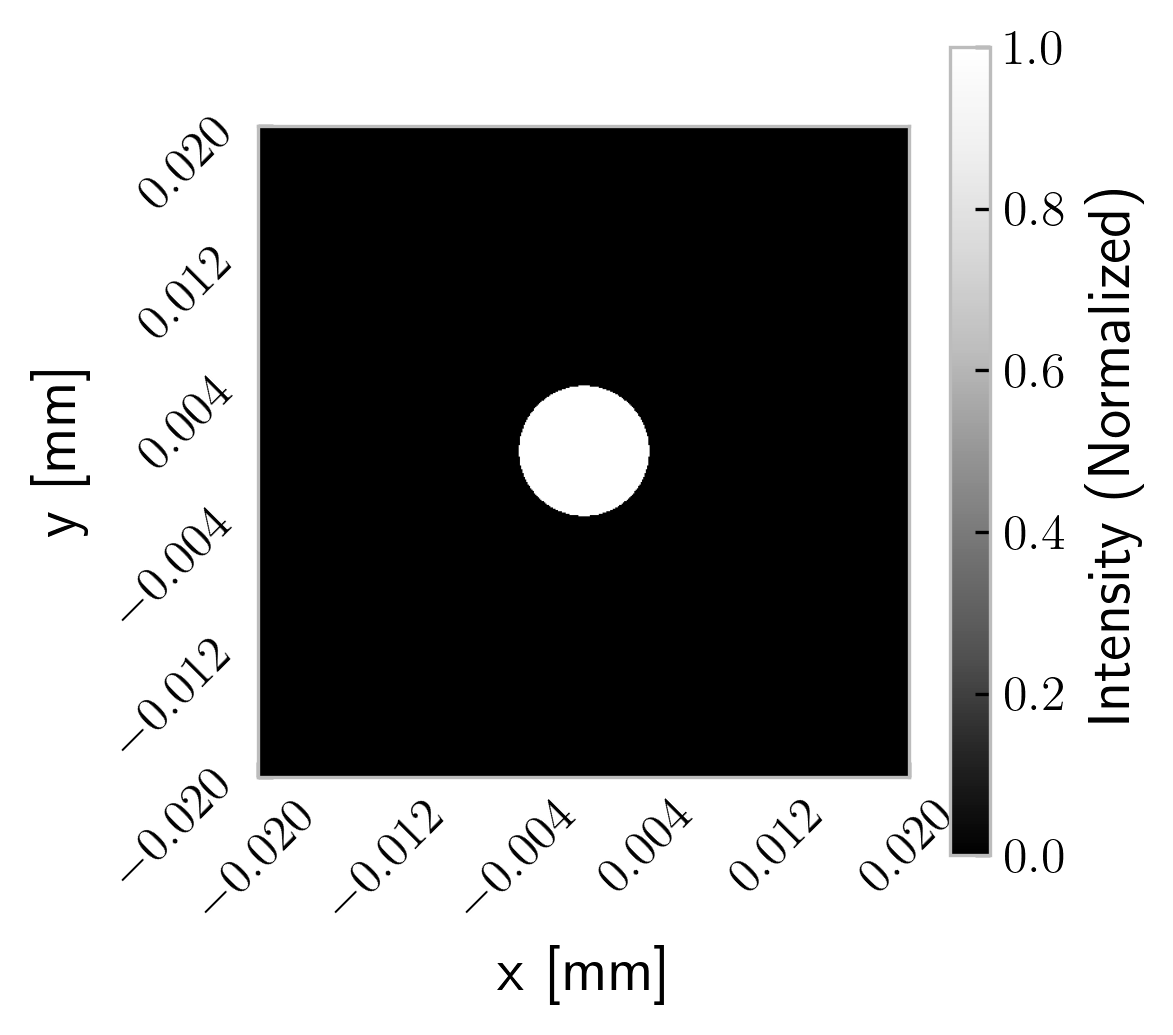

In [5]:
plot_intensity(*bead_img.get_xy(), bead_img.image_mask)
f = bead_img.image_mask

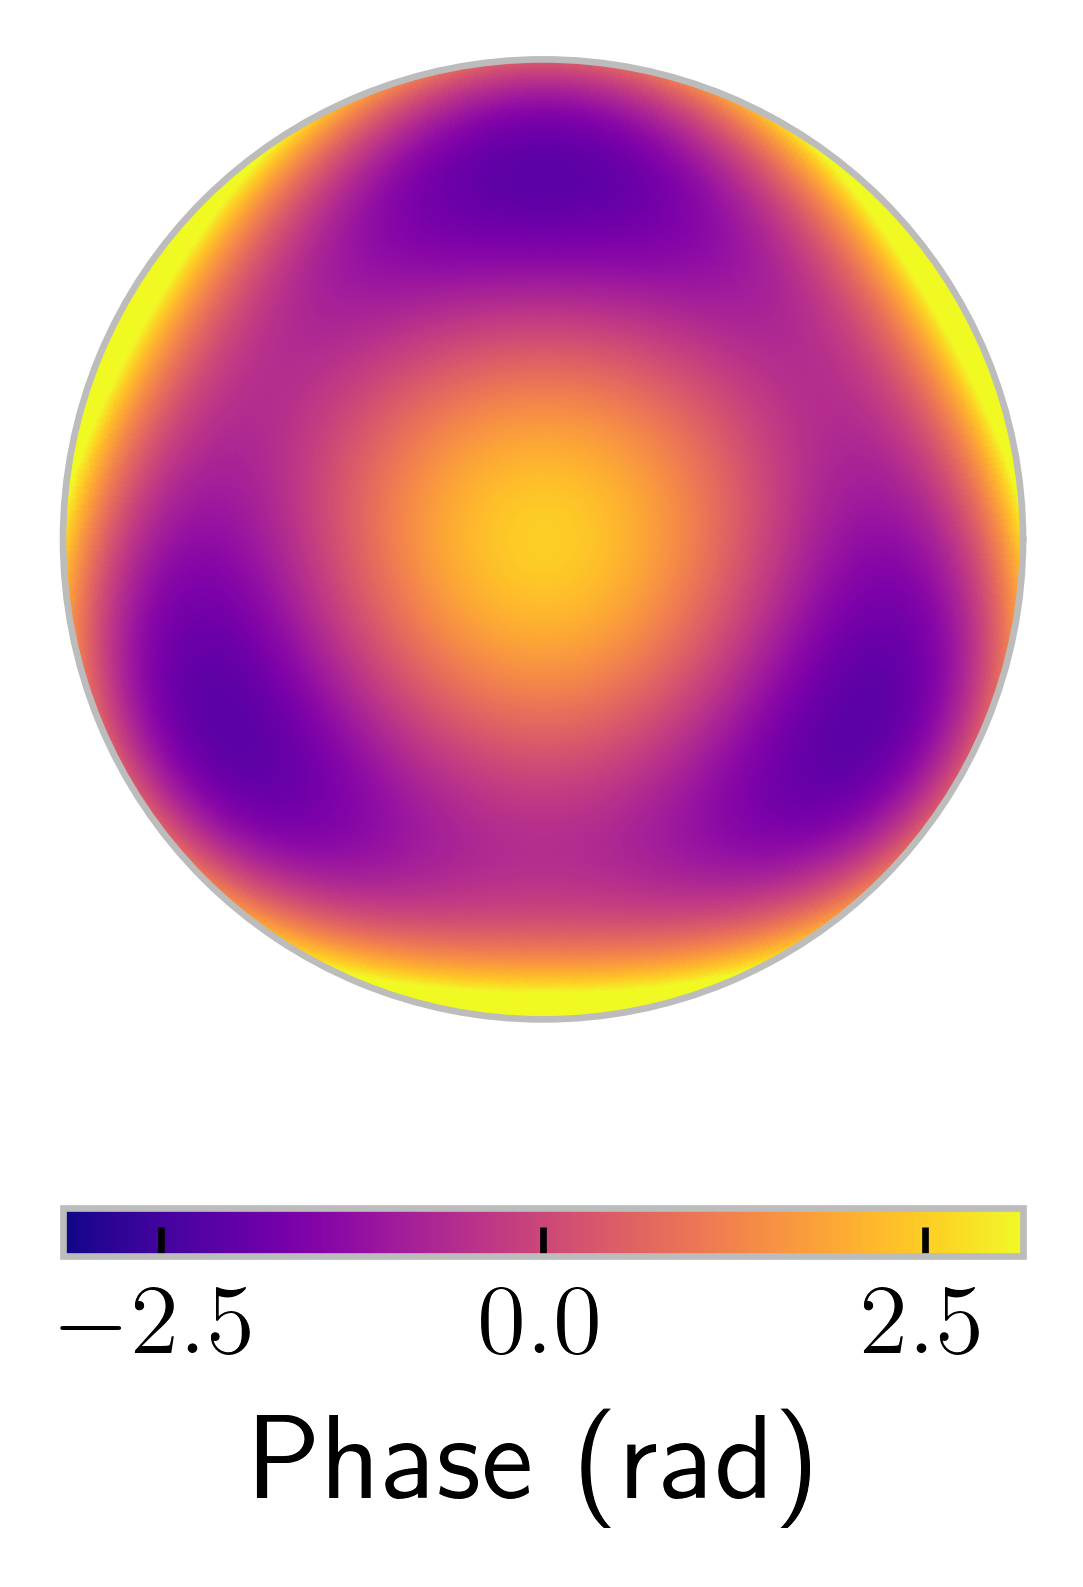

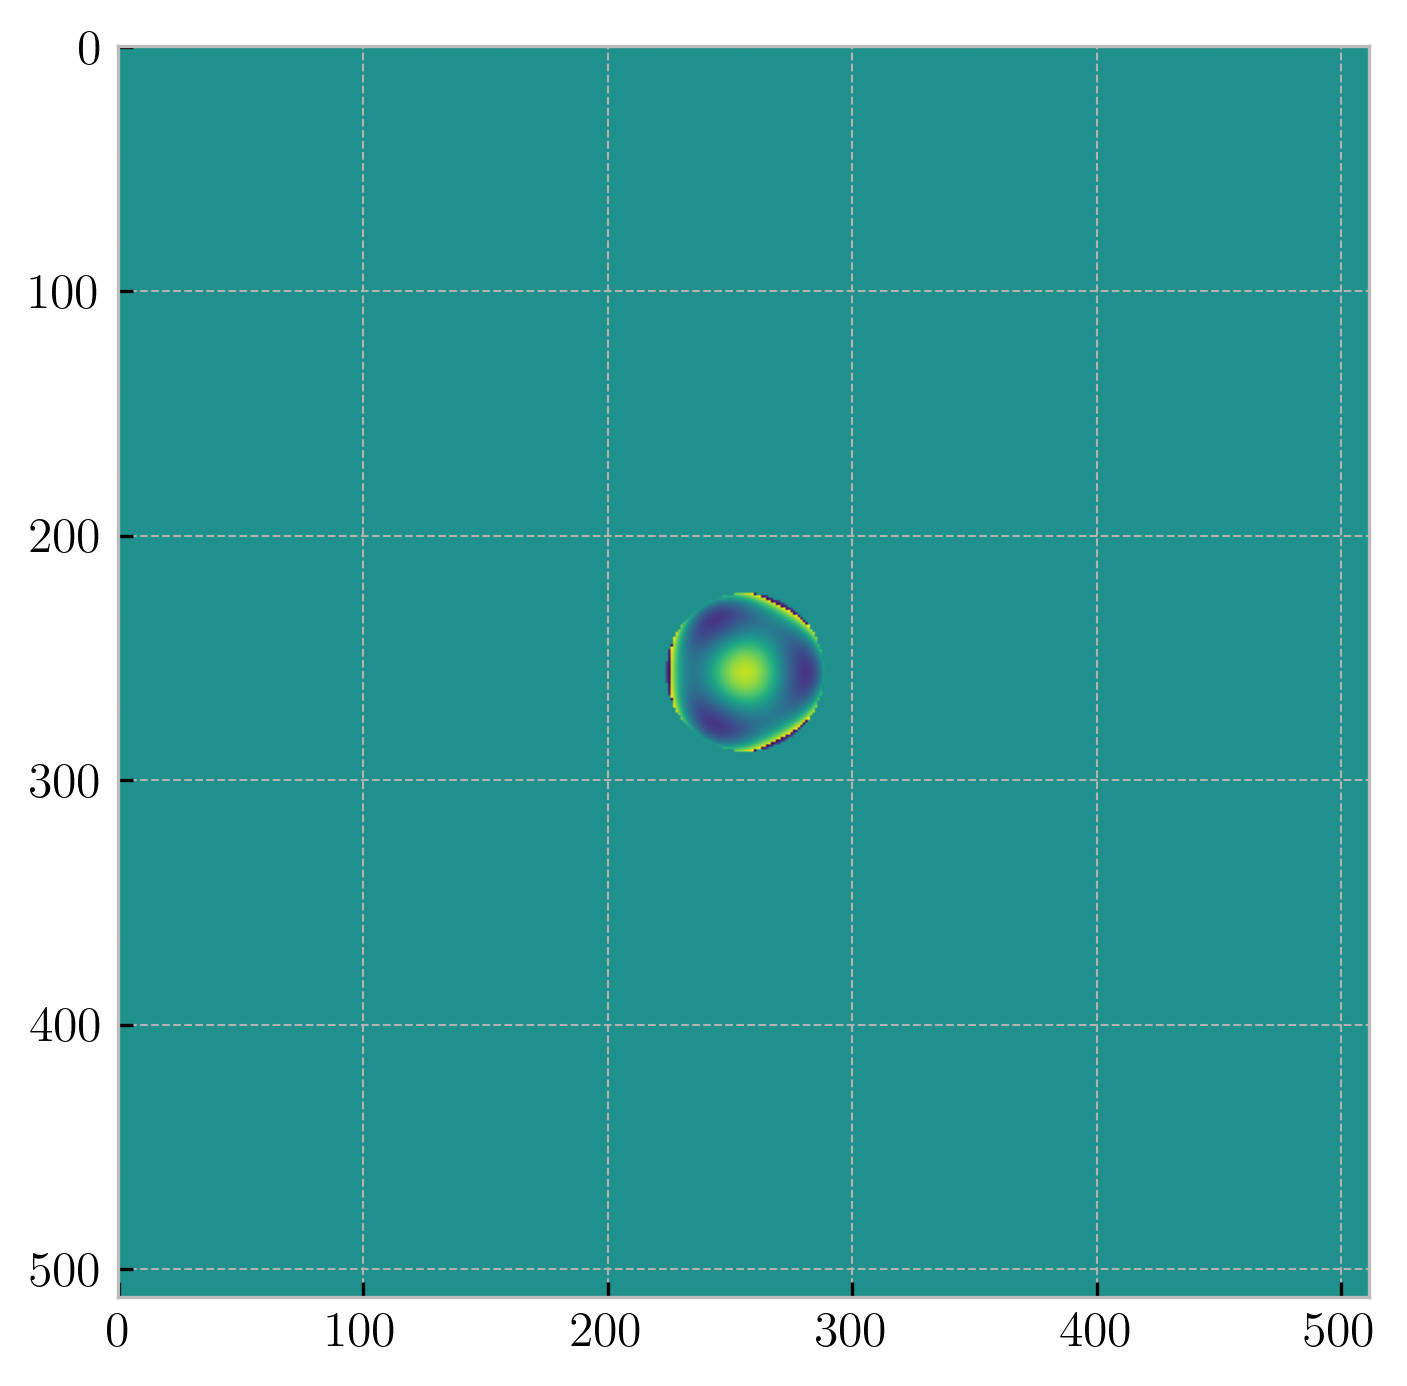

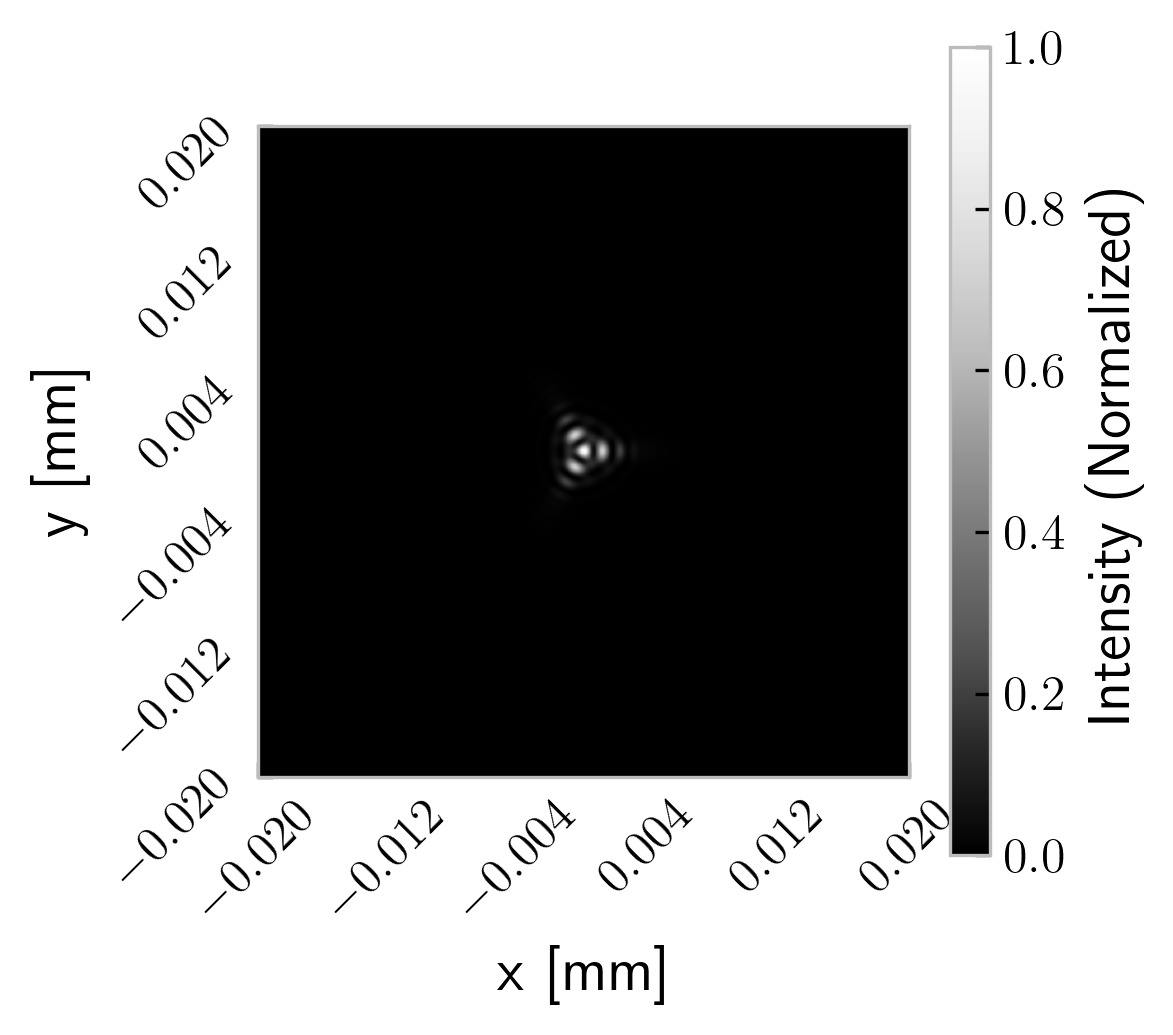

In [6]:
true_modes = [[0, 4], [-3, 3]]
true_c = [0.4, 0.35]
true_aberration = Aberration(true_modes, true_c)
zernike_plot(true_aberration.construct_map(alpha), alpha)
U = microscope.compute_pupil_function(true_aberration)
plt.imshow(np.angle(U))
plt.show()
x, y, s = microscope.compute_scalar_psf(grid, true_aberration)
plot_intensity(x, y, s)

In [7]:
slm = SLM(microscope, bead_img, true_aberration)
convolved_img = slm.get_aberrated_img(mode = "scalar")
def add_poisson(convolved_img, exposure, background, rng = np.random.default_rng(1)):
    #normalize
    convolved_img = (convolved_img - np.min(convolved_img)) / (np.max(convolved_img) - np.min(convolved_img))
    #add poisson
    d = rng.poisson(convolved_img * exposure + background) 
    return d


Getting unaberrated quality...


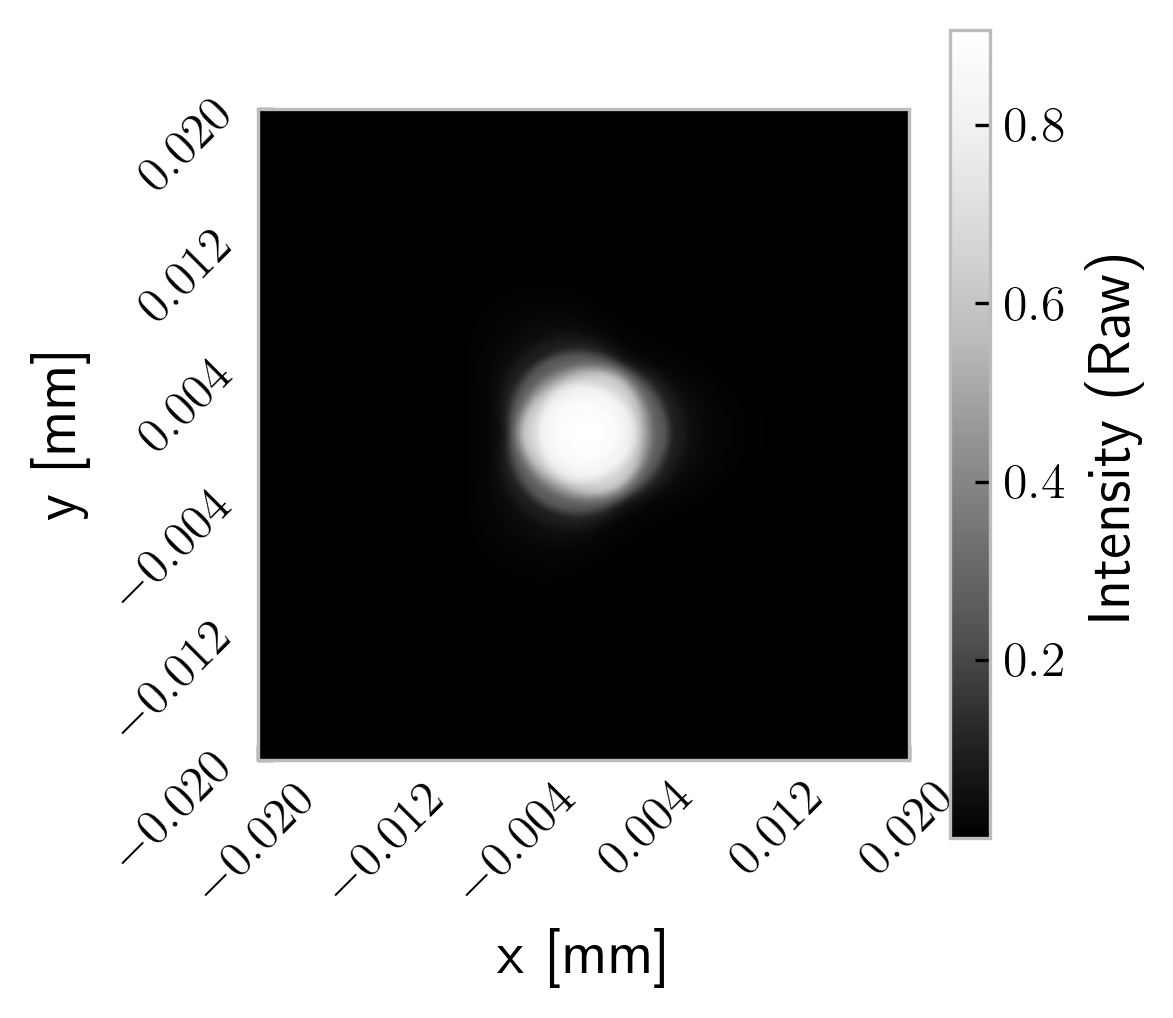

In [8]:
exposure = 10
background = 2

d = convolved_img#add_poisson(convolved_img, exposure, background)
plot_intensity(x, y, d, normalize = False)

Say we have taken $N$ diversity images, indexed with $j$. The pupil function $H_j(\mathbf{u})$ for the $j$-th diversity image where $\mathbf{u}$ is the BFP coordinate is given as follows:

\begin{equation*}
H_j(\mathbf{u}) = |P(\mathbf{u})| e^{ik(\phi(\mathbf{u}) + \theta_j(\mathbf{u}))}
\end{equation*}

where $P$ is the (Gaussian) pupil function, $\phi$ is the unknown sample aberration and $\theta_j$ is the known diversity phase. We treat the sample aberration as a sum of $M$ Zernike modes:
\begin{equation*}
\phi(\mathbf{u}) = \sum_{m=1}^M \langle  \phi(\mathbf{u}), Z_m(\mathbf{u}) \rangle Z_m = \sum_{m=1}^M c_m Z_m
\end{equation*}


Then, we define $h_j(\mathbf{x}) = \mathcal{F}^{-1} (H_j(\mathbf{u}))$. This allows us to write the PSF $s_k(\mathbf{x})$ as:


\begin{equation*}
s_k(\mathbf{x}) = |h_k(\mathbf{x})|^{2p}
\end{equation*}
where $p$ is 1 for 1P, 2 for 2P, etc, and || denotes the complex modulus.

Next, denote the object as $f(\mathbf{x})$ and the $j$-th diversity image as $d_k(\mathbf{x})$. We can write:

\begin{equation*}
d_k(\mathbf{x}) = s_k(\mathbf{x}) \otimes f(\mathbf{x}) + n(\mathbf{x})
\end{equation*}

where $n$ is additive noise and background (likely Poisson or Gaussian)

Now, say that we have estimated the object $f$ and the phase $\phi$ (and by proxy, the PSFs $s_k$). We can write the least-squares objective loss function as follows:

\begin{equation*}
J[\phi, f] = \frac{1}{2} \left[ \sum_{j=1}^N
\int_{\mathbf{x}} [(s_k \otimes f)(\mathbf{x}) - d_k(\mathbf{x})]^2 d \mathbf{x}
\right] + \frac{\gamma}{2} \int_\mathbf{x} [f(x)]^2 d \mathbf{x}
\end{equation*}

where the last term is the ridge-regression penalty, which forces the $L_2$ norm of the object solution $f$ to be small.

For the first step, hold $\phi$ fixed. Now, denote the Fourier transform of our variables by uppercase letters. Since the Fourier transform preserves the $L_2$ norm of a function, we are permitted to write:

\begin{equation*}
J[F] = \frac{1}{2} \int_\mathbf{x} \left[\sum_{j=1}^N |S_k(\mathbf{u}) F(\mathbf{u}) - D_k(\mathbf{u})|^2 + \gamma |F(\mathbf{u})|^2 \right] d \mathbf{y}
\end{equation*}

Via basic expansion and differentiation, we can derive the closed-form minimizer:

\begin{equation*}
\hat{F}(\mathbf{u}) = \frac{\sum_{j=1}^N S_k^*(\mathbf{u}) D_k(\mathbf{u})}{\gamma + \sum_{j=1}^N |S_k(\mathbf{u})|^2}
\end{equation*}

With the optimal object given as:
\begin{equation*}
\hat{f}(\mathbf{u}) = \mathcal{F}^{-1}(\hat{F}(\mathbf{u})) 
\end{equation*}



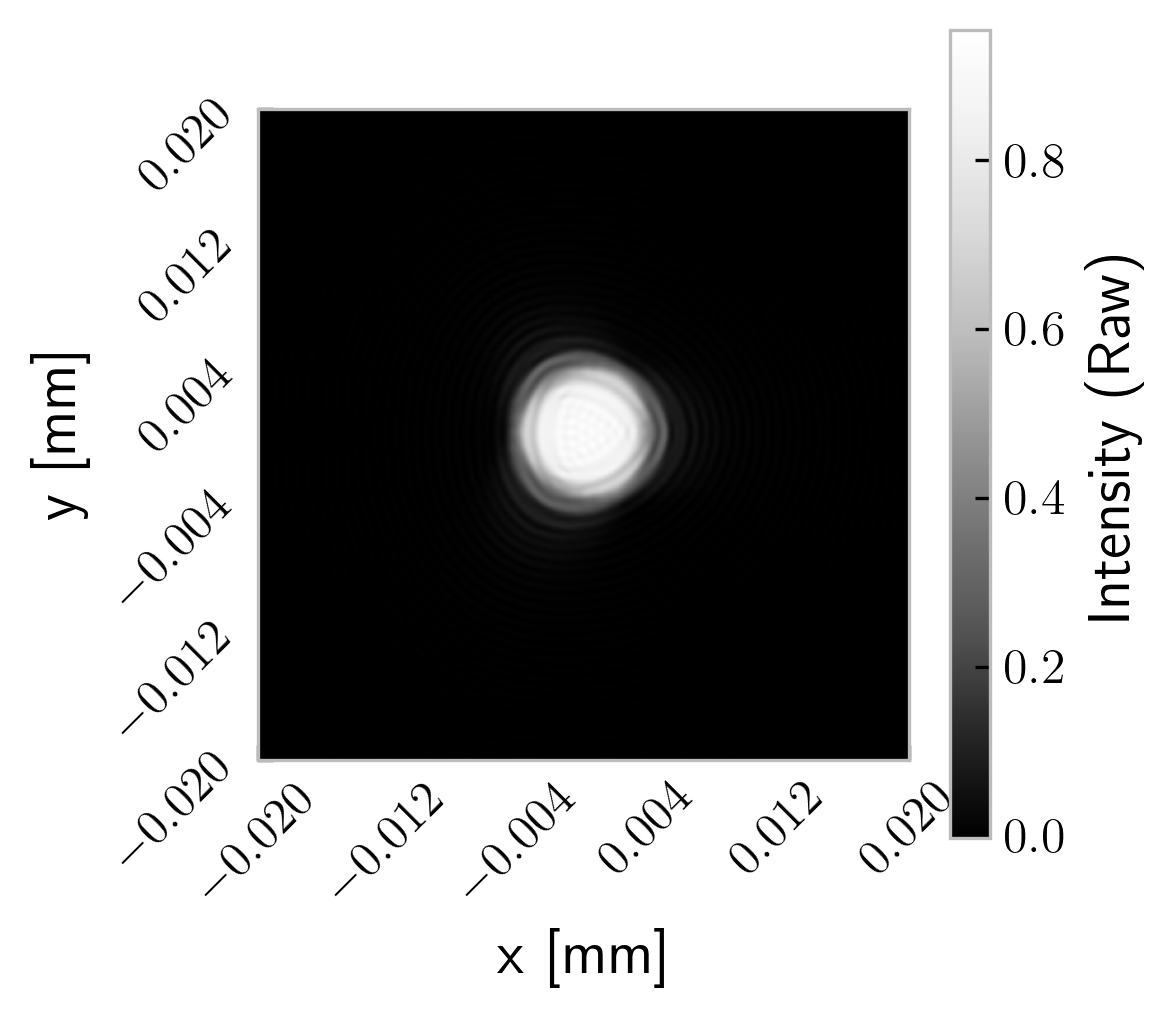

In [24]:
def objective_math(d_stack,
              s_proposed_stack,
              f_proposed,
              gamma):
    
    N = len(d_stack)
    d_hat_stack = [psf_convolve(f_proposed, s) for s in s_proposed_stack]
    J = 0.5 * np.sum([(d_stack[i] - d_hat_stack[i])**2 for i in range(N)]) + 0.5 * gamma * np.sum(f_proposed**2)
    return J

def objective(slm, d_stack,
              a_proposed,
              a_stack,
              f_proposed,
              gamma = .00001):
    #get the pupil functions
    H_stack = [slm.microscope.compute_pupil_function(a + a_proposed) for a in a_stack]
    #get the iffts 
    h_stack = [np.fft.ifft2(H) for H in H_stack]
    #get the stack of PSFS
    s_stack = [np.abs(h)**2 for h in h_stack]
    return objective_math(d_stack, s_stack, f_proposed, gamma)
    
    
def get_diversity_image(slm, diversity_aberration, exposure, background):
    convolved_img = slm.get_corrected_img(diversity_aberration, mode = "scalar")
    d = convolved_img#add_poisson(convolved_img, exposure, background)
    return d

#grid = grid along which the images were taken
#d_stack = list of phase diverse images
#a_stack = list of aberrations applied along each phase diverse image
#aberration_guesss = guess for the inherent sample aberration
#gamma = regularization parameters
def estimate_object(slm,
                    d_stack,
                    a_stack,
                    aberration_guess = EmptyAberration(),
                    gamma = .00001):
    N = len(d_stack)
    #get the pupil functions
    H_stack = [slm.microscope.compute_pupil_function(a + aberration_guess) for a in a_stack]
    #get the iffts 
    h_stack = [np.fft.ifft2(H) for H in H_stack]
    #get the stack of PSFS
    s_stack = [np.abs(h)**2 for h in h_stack]
    #normalize the PSFs
    #take fourier transforms
    S_stack = [np.fft.fft2(s/np.sum(s)) for s in s_stack]

    D_stack = [np.fft.fft2(d) for d in d_stack]
    #compute the estimator
    numerator = np.sum([np.conj(S_stack[j]) * D_stack[j] for j in range(N)], axis = 0)
    denominator = gamma + np.sum([np.abs(S_stack[j])**2 for j in range(N)], axis = 0 )
    F = numerator/denominator 
    f = np.fft.ifft2(F)
    return np.real(f), F

bias_modes = [
    [-2, 2], [0, 2], [2, 2],
    [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4],

]

a_stack = [
    EmptyAberration(),
]

bias_image_stack = [Aberration([m], [0.3]) for m in bias_modes]
a_stack = np.concatenate([a_stack, bias_image_stack])
aberration_guess = EmptyAberration()#true_aberration
d_stack = [get_diversity_image(slm, a, exposure, background) for a in a_stack]

f_guess, F_guess = estimate_object(slm, d_stack, a_stack, EmptyAberration())
plot_intensity(x, y, f_guess, normalize = False)


\begin{equation*}
g[\phi] = -2 \sum_{j=1}^N \Im(H_j^*[\phi] \mathcal{F}(\Re(h_j[\phi] \mathcal{F}^{-1}(V_j[\phi]))))
\end{equation*}

\begin{equation*}
V_j[\phi] = F^*[\phi] D_j - |F[\phi]|^2 S_j[\phi]
\end{equation*}

In [25]:


#grid = grid along which the images were taken
#d_stack = list of phase diverse images
#a_stack = list of aberrations applied along each phase diverse image
#aberration_guesss = guess for the inherent sample aberration
#modes_corrected = list of modes to correct along
#gamma = regularization parameters
def estimate_aberration_gradient(slm,
                    d_stack,
                    a_stack,
                    F_guess,
                    modes_corrected,
                    aberration_guess = EmptyAberration()):
    N = len(d_stack)
    
    D_stack = [np.fft.fft2(d) for d in d_stack]

    #get the pupil functions
    H_stack = [slm.microscope.compute_pupil_function(a + aberration_guess) for a in a_stack]
    #get the iffts 
    h_stack = [np.fft.ifft2(H) for H in H_stack]
    #get the stack of PSFS
    s_stack = [np.abs(h)**2 for h in h_stack]
    #normalize the PSFs
    #take fourier transforms
    S_stack = [np.fft.fft2(s/np.sum(s)) for s in s_stack]

    V_stack = [np.conj(F_guess) * D_stack[i] - np.abs(F_guess)**2 * S_stack[i] for i in range(N)]

    inner_product = [h_stack[i] *  np.real(np.fft.ifft2(V_stack[i])) for i in range(N)]

    g_stack = [np.imag(np.conj(H_stack[i]) * np.fft.fft2(inner_product[i])) for i in range(N) ] 
    g = -2 * np.sum(g_stack, axis = 0) 
    Z_stack = [slm.microscope.compute_phase_map(Aberration([m], [1.0])) for m in modes_corrected]
    #get the component along each zernike
    g_c = np.array([np.sum(g * Z) for Z in Z_stack])
    return g, g_c




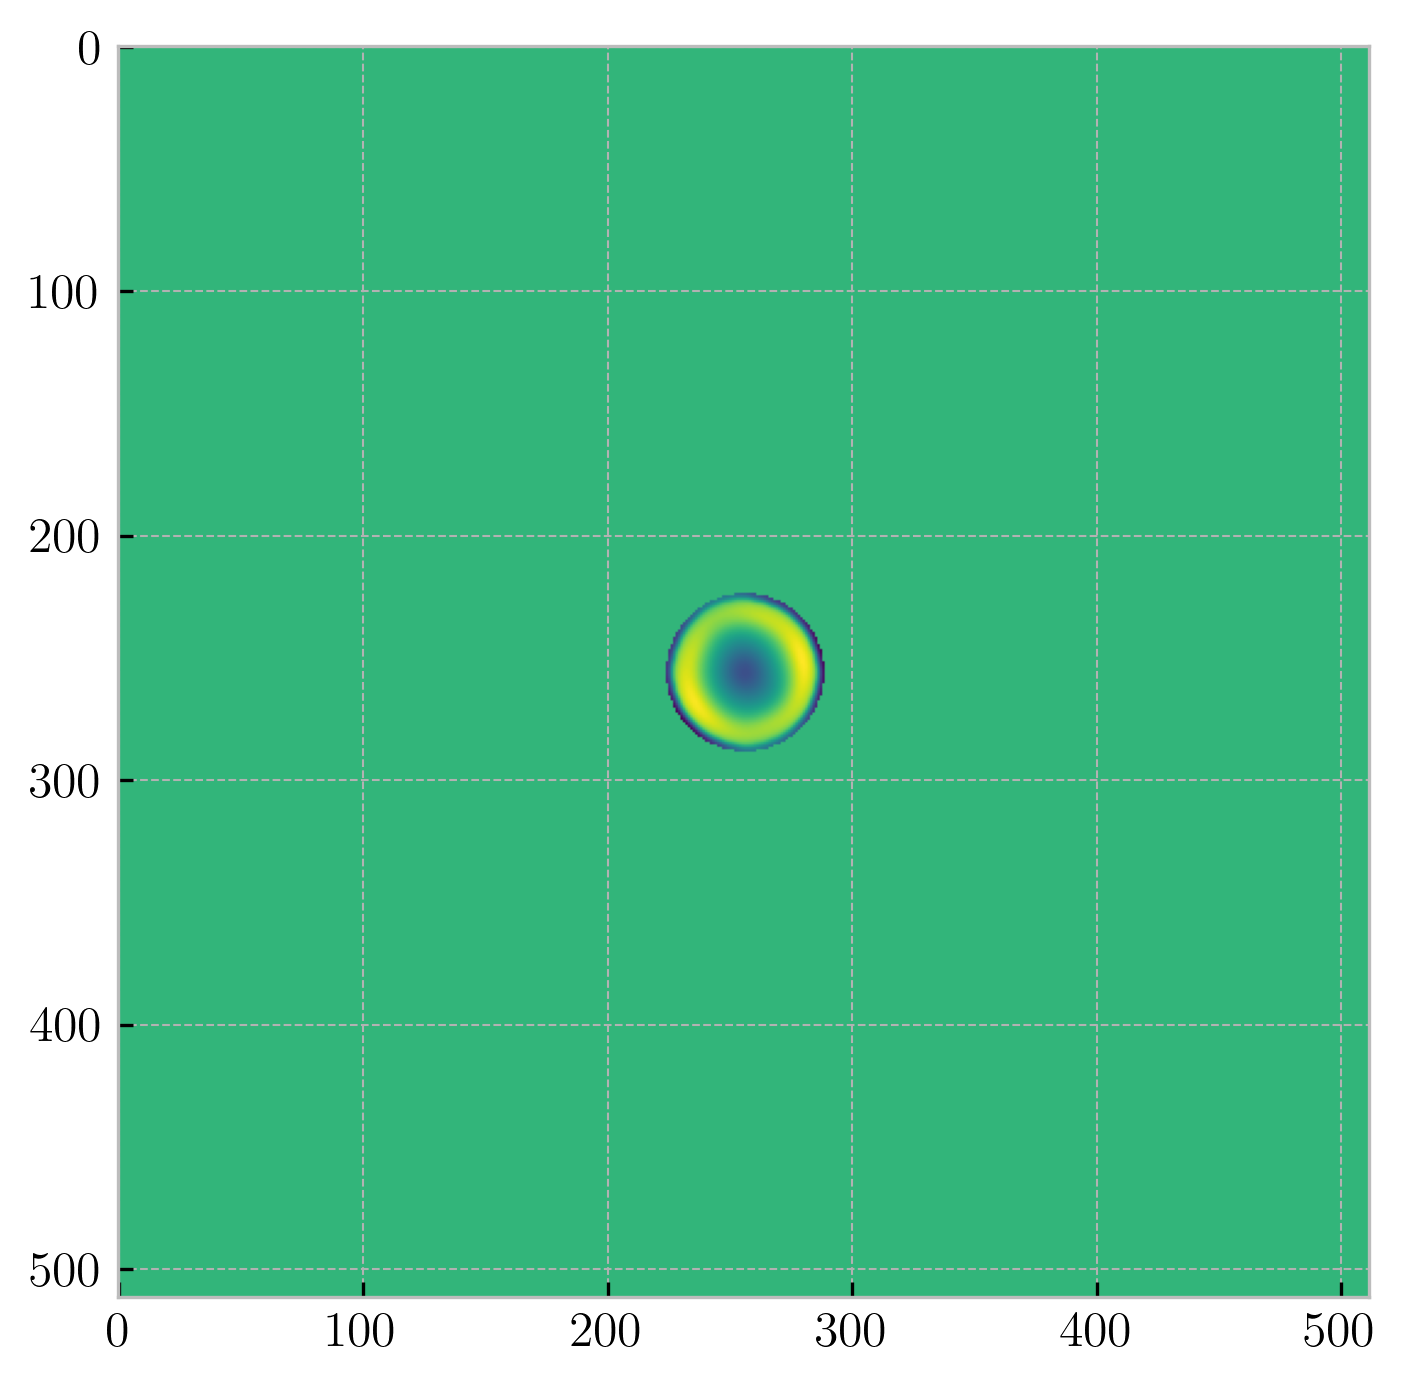

In [26]:
modes_corrected = [
    [-2, 2], [0, 2], [2, 2],
    [-3, 3], [-1, 3], [1, 3], [3, 3],
    [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4],
    [-5, 5], [-3, 5], [-1, 5], [1, 5], [3, 5], [5, 5],
    [-6, 6], [-4, 6], [-2, 6], [0, 6], [2, 6], [4, 6], [6, 6]]

g, g_c = estimate_aberration_gradient(slm, d_stack, a_stack, F_guess, modes_corrected, EmptyAberration())
plt.imshow(g)

In [60]:
coefs = np.linspace(-0.5, .5, 10)
J = [objective(slm, d_stack, Aberration([[-3, 3]], [c]), a_stack, f) for c in coefs]

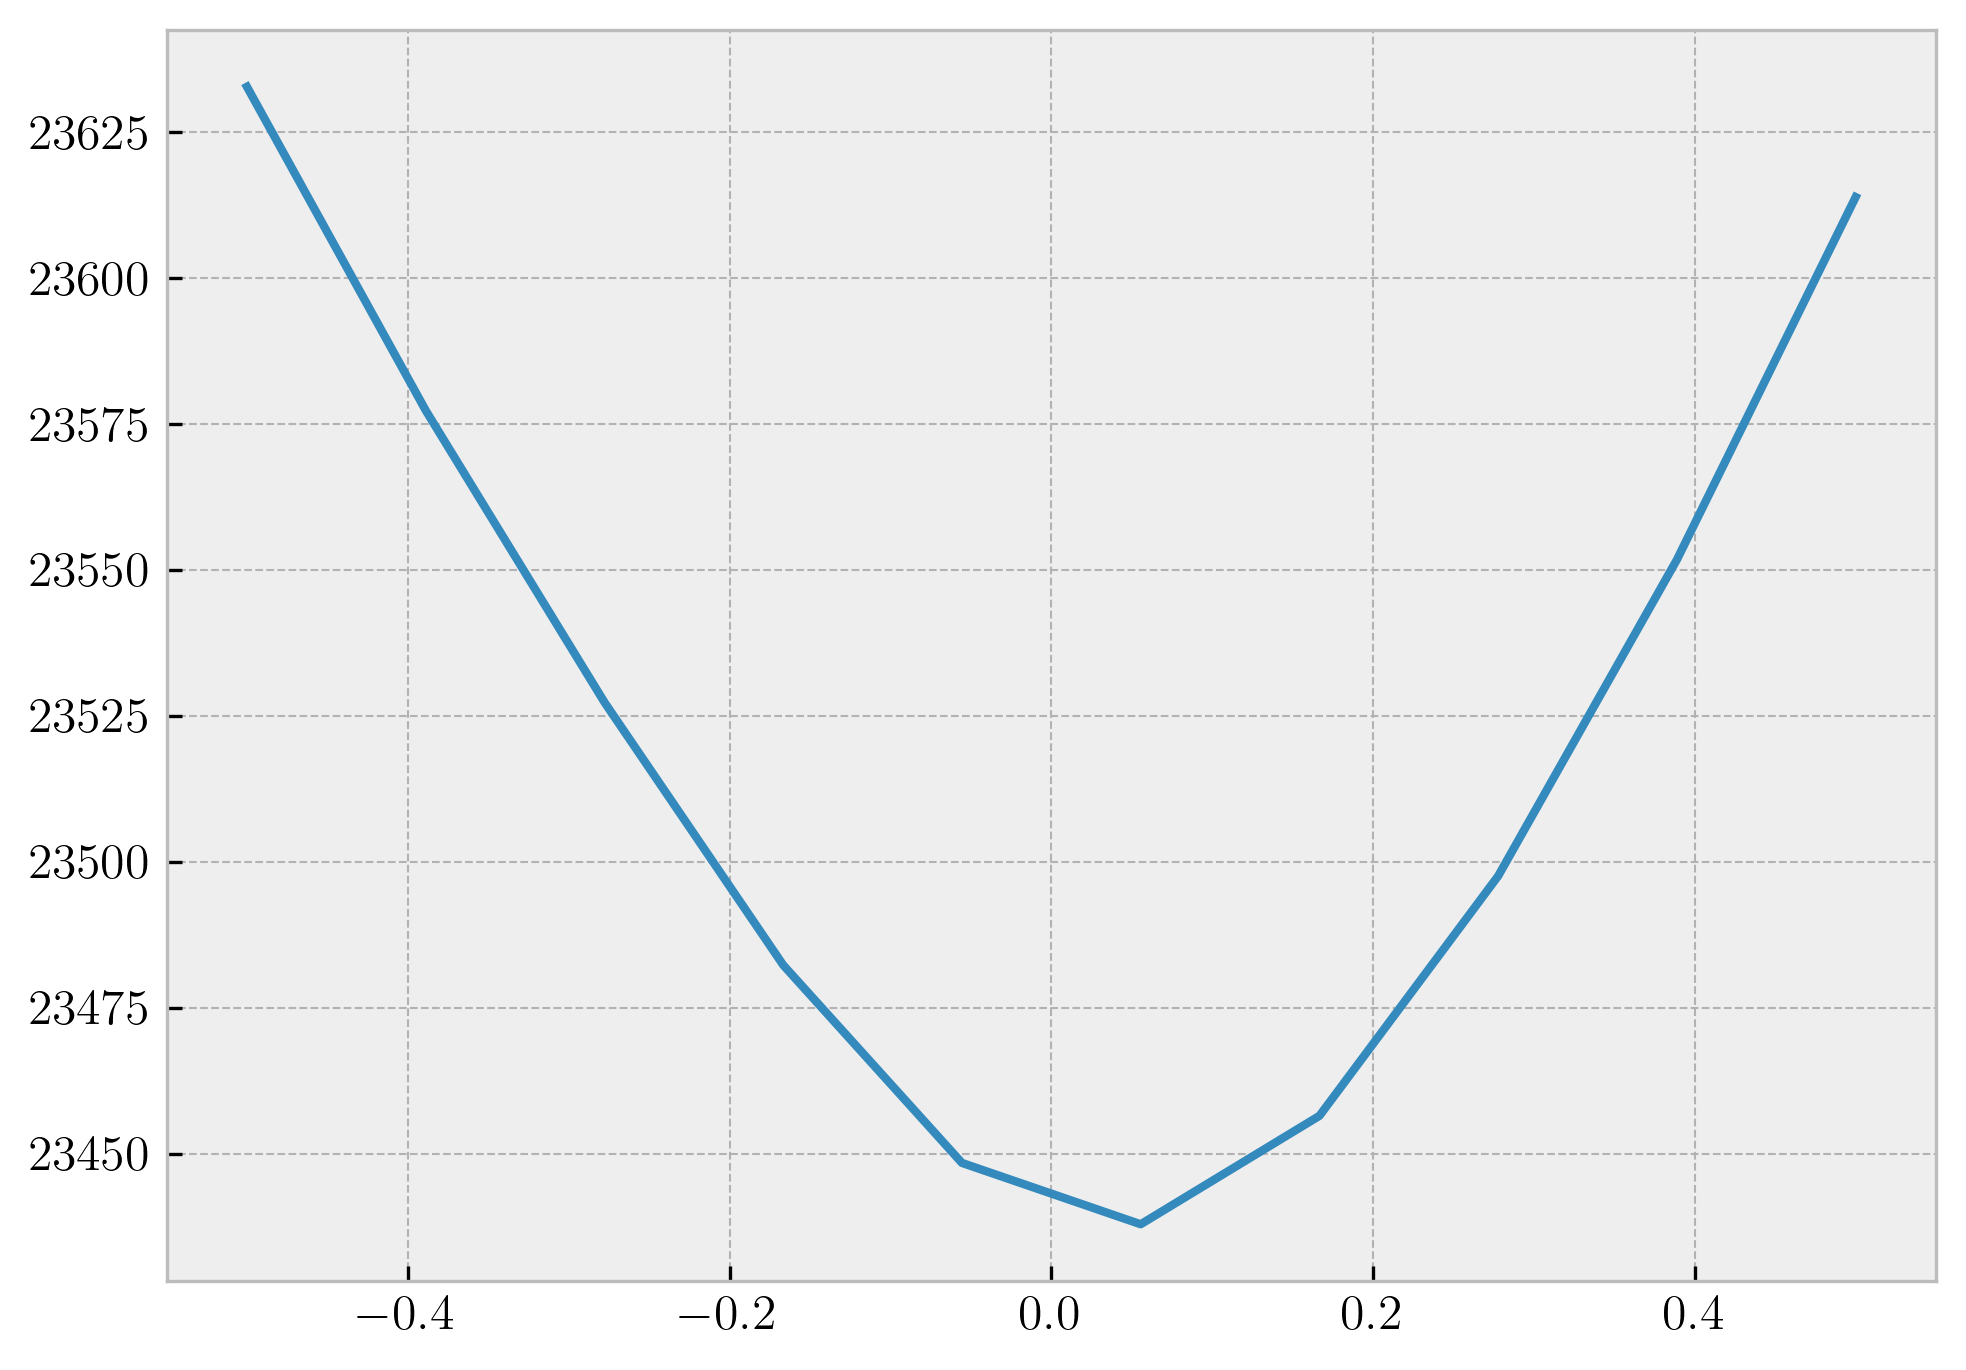

In [61]:
plt.plot(coefs, J)